In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
import datetime

In [221]:
BasePath = '/home/luxiaoling/wukun/MIND/data/large/train/'

In [6]:
behavior_df = pd.read_csv(BasePath+'behaviors.tsv', sep='\t', index_col=0, 
                         names=['impr_id', 'uid', 'impr_time', 'history', 'cur_impr'])
behavior_df.head()

,uid,impr_time,history,cur_impr
impr_id,,,,
1,U87243,11/10/2019 11:30:54 AM,N8668 N39081 N65259 N79529 N73408 N43615 N2937...,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...
2,U598644,11/12/2019 1:45:29 PM,N56056 N8726 N70353 N67998 N83823 N111108 N107...,N47996-0 N82719-0 N117066-0 N8491-0 N123784-0 ...
3,U532401,11/13/2019 11:23:03 AM,N128643 N87446 N122948 N9375 N82348 N129412 N5...,N103852-0 N53474-0 N127836-0 N47925-1
4,U593596,11/12/2019 12:24:09 PM,N31043 N39592 N4104 N8223 N114581 N92747 N1207...,N38902-0 N76434-0 N71593-0 N100073-0 N108736-0...
5,U239687,11/14/2019 8:03:01 PM,N65250 N122359 N71723 N53796 N41663 N41484 N11...,N76209-0 N48841-0 N67937-0 N62235-0 N6307-0 N3...


In [21]:
def utc2local(impr_time):
    date_str, time_str = impr_time.split(maxsplit=1)
    utc_str = datetime.datetime.strptime(date_str, '%m/%d/%Y').strftime('%Y-%m-%d') + ' ' + datetime.datetime.strptime(time_str, '%I:%M:%S %p').strftime('%H:%M:%S')
    utc_datetime = datetime.datetime.strptime(utc_str, '%Y-%m-%d %H:%M:%S')
    dt_str = utc_datetime.strftime('%Y-%m-%d %H:%M:%S')
    return dt_str
behavior_df['impr_datetime'] = behavior_df['impr_time'].apply(utc2local)


In [23]:
behavior_df.sort_values(by='impr_datetime', inplace=True)

In [25]:
save_path = BasePath + 'processed_behavior.csv'
behavior_df[['uid', 'impr_datetime', 'history', 'cur_impr']].to_csv(save_path, sep='\t', header=False, index=False)

In [32]:
behavior_df[behavior_df.history.isnull()].shape

(46065, 5)

In [33]:
def get_seq_len(field):
    try:
        return len(field.split())
    except Exception as e:
        return 0
behavior_df['history_len'] = behavior_df['history'].apply(get_seq_len)
behavior_df['cur_impr_len'] = behavior_df['cur_impr'].apply(get_seq_len)

In [34]:
def get_pos_num(cur_impr):
    flags = [int(x[-1]) for x in cur_impr.split()]
    return sum(flags)
behavior_df['pos_num'] = behavior_df['cur_impr'].apply(get_pos_num)

In [35]:
behavior_df.head()

,uid,impr_time,history,cur_impr,impr_datetime,history_len,cur_impr_len,pos_num
impr_id,,,,,,,,
472831,U403465,11/9/2019 12:00:00 AM,N59850 N104930 N68866 N82374 N123325 N127916 N...,N92613-0 N17456-0 N67369-0 N31486-0 N76810-0 N...,2019-11-09 00:00:00,37,35,1
526311,U493092,11/9/2019 12:00:02 AM,N3960 N115631 N21659 N79594 N128643 N52938 N12...,N6865-0 N128031-0 N79990-0 N121426-0 N2198-0 N...,2019-11-09 00:00:02,78,18,1
709414,U172654,11/9/2019 12:00:03 AM,N43253 N119785 N81937 N128965 N58990 N74795 N7...,N65783-1 N119284-0 N76810-0,2019-11-09 00:00:03,12,3,1
1626676,U248125,11/9/2019 12:00:07 AM,N102417 N22902 N95420 N81970 N24696 N115565 N9...,N90042-0 N2598-0 N108809-0 N104610-0 N18956-0 ...,2019-11-09 00:00:07,12,42,2
1104144,U495159,11/9/2019 12:00:13 AM,N88765 N74317 N63723 N121794 N95711 N64341 N75...,N104437-0 N76810-0 N98657-0 N25492-0 N108809-0...,2019-11-09 00:00:13,56,23,1


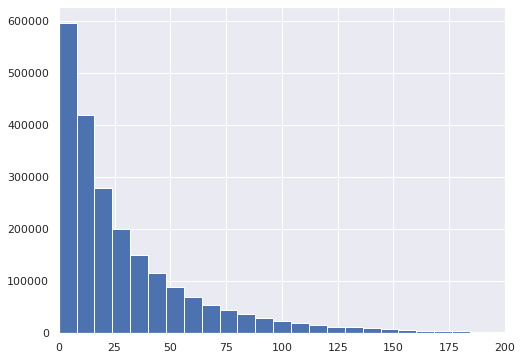

In [38]:
plt.figure(figsize=(8, 6))
behavior_df['history_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

In [39]:
behavior_df.history_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90     79.0
0.91     83.0
0.92     89.0
0.93     95.0
0.94    102.0
0.95    110.0
0.96    120.0
0.97    135.0
0.98    155.0
0.99    194.0
Name: history_len, dtype: float64

In [41]:
pos_num_all = behavior_df.pos_num.sum()
impr_num_all = behavior_df.cur_impr_len.sum()
print(pos_num_all, impr_num_all, float(pos_num_all) / impr_num_all)

3383656 83507374 0.04051924803670631


In [42]:
behavior_df.tail()
# 时间跨度 11.09 - 11.14

,uid,impr_time,history,cur_impr,impr_datetime,history_len,cur_impr_len,pos_num
impr_id,,,,,,,,
111,U286542,11/14/2019 11:59:54 PM,N57681 N112546 N53796 N62205 N116171 N85428 N3...,N82503-0 N82316-0 N26122-0 N19586-0 N80770-0 N...,2019-11-14 23:59:54,24,17,1
1402060,U416061,11/14/2019 11:59:54 PM,N35125 N48862 N33286 N84500 N16005,N34980-0 N63322-0 N51651-0 N125720-0 N77013-0 ...,2019-11-14 23:59:54,5,87,1
1108376,U302411,11/14/2019 11:59:54 PM,N95088,N82503-0 N78508-0 N83707-0 N82316-0 N67937-0 N...,2019-11-14 23:59:54,1,17,2
267635,U499131,11/14/2019 11:59:59 PM,N55903 N112061 N106533,N49978-0 N83732-0 N106619-0 N28861-0 N45410-0 ...,2019-11-14 23:59:59,3,114,1
676391,U403739,11/14/2019 11:59:59 PM,N119708 N54948 N112152 N94450 N68960 N39785 N8...,N8236-0 N82503-0 N80770-0 N118623-0 N83707-0 N...,2019-11-14 23:59:59,16,13,1


In [222]:
behavior_val_path = '/home/luxiaoling/wukun/MIND/data/large/dev/behaviors.tsv'
behavior_val_df = pd.read_csv(behavior_val_path, sep='\t', index_col=0, 
                         names=['impr_id', 'uid', 'impr_time', 'history', 'cur_impr'])
behavior_val_df.head()

,uid,impr_time,history,cur_impr
impr_id,,,,
1,U134050,11/15/2019 8:55:22 AM,N12246 N128820 N119226 N4065 N67770 N33446 N10...,N91737-0 N30206-0 N54368-0 N117802-0 N18190-0 ...
2,U254959,11/15/2019 11:42:35 AM,N34011 N9375 N67397 N7936 N118985 N109453 N103...,N119999-0 N24958-0 N104054-0 N33901-0 N9250-0 ...
3,U499841,11/15/2019 9:08:21 AM,N63858 N26834 N6379 N85484 N15229 N65119 N1047...,N18190-0 N89764-0 N91737-0 N54368-0 N49978-1 N...
4,U107107,11/15/2019 5:50:31 AM,N12959 N8085 N18389 N3758 N9740 N90543 N129790...,N122944-1 N18190-0 N55801-0 N59297-0 N128045-0...
5,U492344,11/15/2019 5:02:25 AM,N109183 N48453 N85005 N45706 N98923 N46069 N35...,N64785-0 N82503-0 N32993-0 N122944-0 N29160-0 ...


In [223]:
behavior_val_df['history_len'] = behavior_val_df['history'].apply(get_seq_len)
behavior_val_df.history_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90     79.0
0.91     83.0
0.92     88.0
0.93     94.0
0.94    101.0
0.95    109.0
0.96    119.0
0.97    134.0
0.98    153.0
0.99    191.0
Name: history_len, dtype: float64

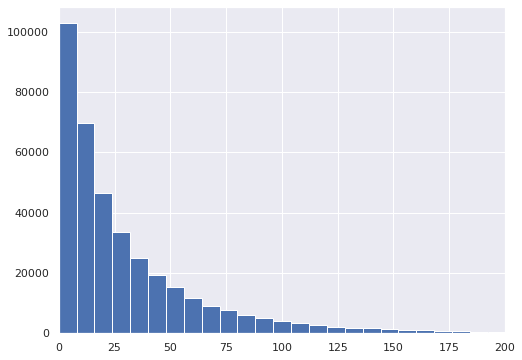

In [224]:
plt.figure(figsize=(8, 6))
behavior_val_df['history_len'].hist(bins=100)
plt.xlim(0, 200)
plt.show()

In [225]:
# 统计验证集中 新用户比例 和 新new比例
uid_set_train = set(behavior_df['uid'])
uid_set_val = set(behavior_val_df['uid'])
new_user_set = uid_set_val - uid_set_train
len(uid_set_train), len(uid_set_val), len(new_user_set), len(new_user_set) / len(uid_set_val)

(711222, 255990, 39212, 0.15317785851009805)

In [236]:
def get_news_set(df, history=False):
    history_set = set()
    impr_set = set()
    for imprs in df['cur_impr']:
        news = [x[:-2] for x in imprs.split()]
        impr_set.update(news)
    if history:
        for news in df['history']:
            try:
                history_set.update(news.split())
            except Exception as e:
                continue
    return history_set | impr_set
news_set_train = get_news_set(behavior_df, history=True)
news_set_val = get_news_set(behavior_val_df)
new_news = news_set_val - news_set_train
len(news_set_train), len(news_set_val), len(new_news), len(new_news) / len(news_set_val)

(101527, 6997, 2244, 0.3207088752322424)

In [269]:
## 保存新用户和新新闻
with open('./data/large/dev/new_user.csv', 'w') as f:
    line = ' '.join(new_user_set)
    f.write(line)
    
with open('./data/large/dev/new_news.csv', 'w') as f:
    line = ' '.join(new_news)
    f.write(line)

In [ ]:
# 编码 news_id 和 user_id


In [237]:
# check 训练集中出现的news是否都在news.tsv中有对应数据
all_news_train_set = set(news_df.news_id)
len(news_set_train - all_news_train_set)

9

In [238]:
news_set_val_impr_history = get_news_set(behavior_val_df, history=True)
all_news_val_set = set(news_val_df.news_id)
len(news_set_val_impr_history - all_news_val_set)

3

In [239]:
print(news_set_train - all_news_train_set)
print(news_set_val_impr_history - all_news_val_set)

{'N45822', 'N65580', 'N56607', 'N126933', 'N1909', 'N53215', 'N98898', 'N107620', 'N115431'}
{'N128031', 'N45822', 'N98898'}


In [240]:
{'N128031', 'N45822', 'N98898'} & all_news_train_set

{'N128031'}

In [241]:
{'N45822', 'N65580', 'N56607', 'N126933', 'N1909', 'N53215', 'N98898', 'N107620', 'N115431'} & all_news_val_set

{'N126933', 'N1909', 'N53215'}

### deepwalk预训练user和new embedding

In [86]:
news_df = pd.read_csv(BasePath+'news_with_body.tsv', sep='\t',
                         names=['news_id', 'category', 'subcategory', 'title', 'abstract', 'link', 'title_entity', 'abstract_entity', 'body'])

news_df.head()

,news_id,category,subcategory,title,abstract,link,title_entity,abstract_entity,body
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],The royals are free to shop wherever they choo...
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,https://assets.msn.com/labs/mind/AABmf2I.html,"[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","This year, Walmart’s not waiting until to offe..."
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","When you first start dieting and exercising, t..."
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[],"CINCINNATI (FOX19) - If you have expired, unus..."
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...","ZOLOTE, Ukraine — Lt. Ivan Molchanets peeked o..."


In [87]:
news_df.isnull().sum()

news_id               0
category              0
subcategory           0
title                 0
abstract           5415
link                  0
title_entity          0
abstract_entity       1
body                271
dtype: int64

In [88]:
import re
def get_text_len(text):
    try:
        return len(re.split(r'[ ,.?]', text))
    except Exception as e:
        return 0
news_df['title_len'] = news_df.title.apply(get_text_len)
news_df['abstract_len'] = news_df.abstract.apply(get_text_len)
news_df['body_len'] = news_df.body.apply(get_text_len)

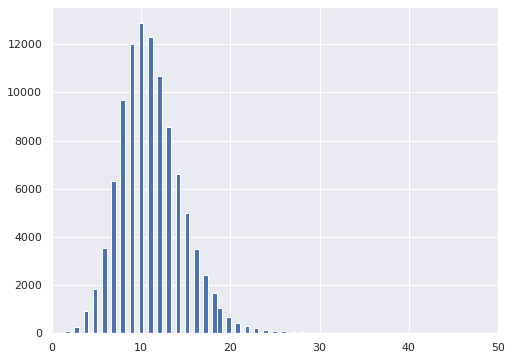

In [89]:
plt.figure(figsize=(8, 6))
news_df['title_len'].hist(bins=200)
plt.xlim(0, 50)
plt.show()

In [90]:
news_df.title_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90    16.0
0.91    16.0
0.92    16.0
0.93    17.0
0.94    17.0
0.95    17.0
0.96    18.0
0.97    19.0
0.98    20.0
0.99    22.0
Name: title_len, dtype: float64

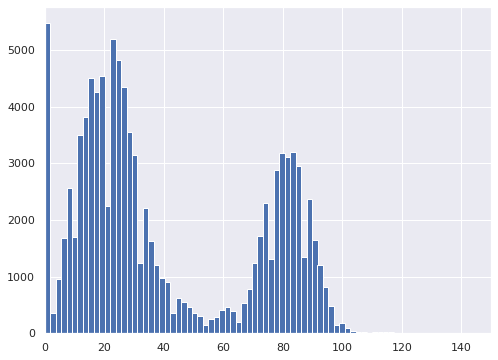

In [91]:
plt.figure(figsize=(8, 6))
news_df['abstract_len'].hist(bins=300)
plt.xlim(0, 150)
plt.show()

In [92]:
news_df.abstract_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90    85.0
0.91    86.0
0.92    87.0
0.93    88.0
0.94    88.0
0.95    89.0
0.96    91.0
0.97    92.0
0.98    94.0
0.99    97.0
Name: abstract_len, dtype: float64

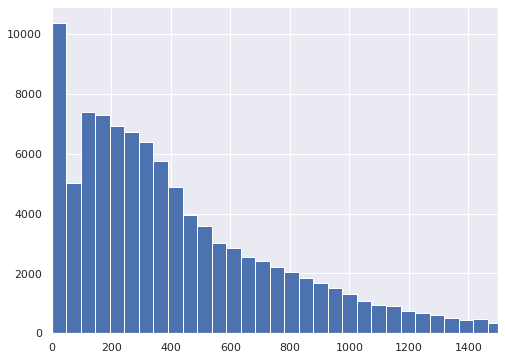

In [98]:
plt.figure(figsize=(8, 6))
news_df['body_len'].hist(bins=800)
plt.xlim(0, 1500)
plt.show()

In [99]:
news_df.body_len.quantile([0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

0.90    1099.00
0.91    1153.00
0.92    1214.00
0.93    1290.00
0.94    1383.00
0.95    1495.00
0.96    1649.00
0.97    1863.49
0.98    2211.00
0.99    2907.66
Name: body_len, dtype: float64

In [100]:
news_df.category.value_counts()

sports           32018
news             30474
finance           5916
travel            4955
video             4569
lifestyle         4569
foodanddrink      4418
weather           4255
autos             3071
health            2928
tv                1323
music             1262
entertainment      837
movies             815
kids               104
middleeast           2
games                1
northamerica         1
Name: category, dtype: int64

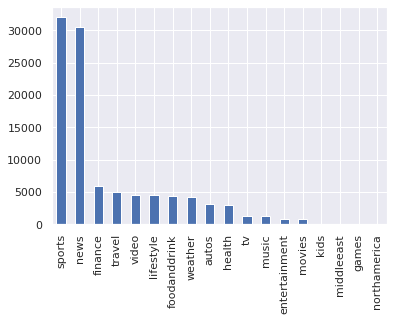

In [101]:
news_df.category.value_counts().plot(kind='bar')
plt.show()

In [102]:
news_df.subcategory.nunique()

285

In [103]:
news_df.subcategory.value_counts()

newsus                    14467
football_nfl              11812
newspolitics               5142
weathertopstories          4253
newscrime                  3676
                          ...  
finance-auto-insurance        1
games                         1
games-news                    1
tv                            1
shop-toys                     1
Name: subcategory, Length: 285, dtype: int64

In [104]:
def text2lower(text):
    try:
        return text.lower()
    except Exception as e:
        return ''
news_df['title_lower'] = news_df['title'].apply(lambda x: x.lower())
news_df['abstract_lower'] = news_df['abstract'].apply(text2lower)
news_df['body_lower'] = news_df['body'].apply(text2lower)
news_df['title_abstract_body'] = news_df['title_lower'] + ['. '] * news_df.shape[0] + news_df['abstract_lower'] + ['. '] * news_df.shape[0] + news_df['body_lower']


In [105]:
news_df.head()

,news_id,category,subcategory,title,abstract,link,title_entity,abstract_entity,body,title_len,abstract_len,body_len,title_lower,abstract_lower,body_lower,title_abstract_body
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],The royals are free to shop wherever they choo...,13,15,930,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",the royals are free to shop wherever they choo...,"the brands queen elizabeth, prince charles, an..."
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,https://assets.msn.com/labs/mind/AABmf2I.html,"[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","This year, Walmart’s not waiting until to offe...",6,12,386,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,"this year, walmart’s not waiting until to offe...",walmart slashes prices on last-generation ipad...
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","When you first start dieting and exercising, t...",6,20,7838,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,"when you first start dieting and exercising, t...",50 worst habits for belly fat. these seemingly...
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[],"CINCINNATI (FOX19) - If you have expired, unus...",11,0,185,dispose of unwanted prescription drugs during ...,,"cincinnati (fox19) - if you have expired, unus...",dispose of unwanted prescription drugs during ...
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...","ZOLOTE, Ukraine — Lt. Ivan Molchanets peeked o...",12,40,1719,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,"zolote, ukraine — lt. ivan molchanets peeked o...",the cost of trump's aid freeze in the trenches...


In [106]:
news_df.title_abstract_body[0]

'the brands queen elizabeth, prince charles, and prince philip swear by. shop the notebooks, jackets, and more that the royals can\'t live without.. the royals are free to shop wherever they choose, but they tend to keep it in the family—the royal warrant family, that is.the precious few brands with royal warrants are permitted display the royal arms in their marketing materials. the royals usually refuse to promote commercial goods, but the warrants are a rare and prominent exception. they\'re an obvious boon to any branding efforts, but getting your hands on one is no easy task. first, a company must provide goods or services to the royal family (or more specifically, to queen elizabeth, prince philip, and prince charles, the three royals able to award warrants) for five years. then, as nigel fulton, owner of royal warrantee fulton umbrellas, told town & country earlier this year, "you have to wait until you’re invited to apply, so it’s not automatic at all." to apply, companies need

In [41]:
import gensim
from gensim import corpora, models
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.stem.porter import *
import nltk
# nltk.download('wordnet')

In [42]:
stemmer = SnowballStemmer('english')
def lemmatize_stemming(text):
    return stemmer.stem(WordNetLemmatizer().lemmatize(text, pos='v'))
 
def preprocess(text):
    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 2:
            result.append(lemmatize_stemming(token))
    return result

In [110]:
preprocess(news_df.title_abstract_body[0])

['brand',
 'queen',
 'elizabeth',
 'princ',
 'charl',
 'princ',
 'philip',
 'swear',
 'shop',
 'notebook',
 'jacket',
 'royal',
 'live',
 'royal',
 'free',
 'shop',
 'choos',
 'tend',
 'famili',
 'royal',
 'warrant',
 'famili',
 'precious',
 'brand',
 'royal',
 'warrant',
 'permit',
 'display',
 'royal',
 'arm',
 'market',
 'materi',
 'royal',
 'usual',
 'refus',
 'promot',
 'commerci',
 'good',
 'warrant',
 'rare',
 'promin',
 'except',
 'obvious',
 'boon',
 'brand',
 'effort',
 'get',
 'hand',
 'easi',
 'task',
 'compani',
 'provid',
 'good',
 'servic',
 'royal',
 'famili',
 'specif',
 'queen',
 'elizabeth',
 'princ',
 'philip',
 'princ',
 'charl',
 'royal',
 'abl',
 'award',
 'warrant',
 'year',
 'nigel',
 'fulton',
 'owner',
 'royal',
 'warrante',
 'fulton',
 'umbrella',
 'tell',
 'town',
 'countri',
 'earlier',
 'year',
 'wait',
 'invit',
 'appli',
 'automat',
 'appli',
 'compani',
 'need',
 'submit',
 'laundri',
 'list',
 'disclosur',
 'ensur',
 'busi',
 'meet',
 'standard',
 'fi

In [111]:
news_df['processed_title_abstract_body'] = news_df['title_abstract_body'].apply(preprocess)

In [117]:
dictionary = gensim.corpora.Dictionary(news_df['processed_title_abstract_body'])
dictionary.filter_extremes(no_below=10, no_above=0.5)
len(dictionary)

33696

In [118]:
dic_save_path = BasePath + 'gensim_dictionary'
dictionary.save_as_text(dic_save_path)

In [119]:
corpus = [dictionary.doc2bow(doc) for doc in news_df['processed_title_abstract_body']]

In [125]:
# 划分训练和验证corpus
import random
random.shuffle(corpus)
train_size = int(0.9 * len(corpus))
train_corpus = corpus[:train_size]
val_corpus = corpus[train_size:]

In [126]:
from gensim.models import CoherenceModel
topics = [30, 50, 80, 100, 150, 200]
coherence_scores = []
bst_lda = None
bst_coherence = 0
for topic_num in topics:
    lda_model = gensim.models.LdaMulticore(train_corpus, num_topics=topic_num, id2word=dictionary, workers=8)
    cm = CoherenceModel(model=lda_model, corpus=val_corpus, coherence='u_mass')
    coherence = cm.get_coherence()
    coherence_scores.append(coherence)
    print(topic_num, coherence)
    if coherence > bst_coherence:
        bst_coherence = coherence
        bst_lda = lda_model

30 -1.2701404760358896
50 -1.3408039177271933
80 -1.3523242134207476
100 -1.4327932086353103
150 -1.4847181801730556
200 -1.555510386010349


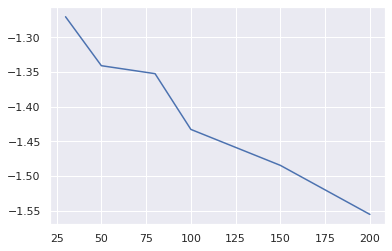

In [131]:
plt.plot(topics, coherence_scores)
plt.show()

In [138]:
bst_lda = gensim.models.LdaMulticore(corpus, num_topics=80, id2word=dictionary, workers=8)

In [145]:
for idx, topic in lda_model.print_topics(20, 15):
    print('Topic: {} \nWords: {}'.format(idx, topic))

Topic: 35 
Words: 0.008*"retir" + 0.008*"save" + 0.006*"shop" + 0.005*"holiday" + 0.004*"like" + 0.004*"day" + 0.004*"money" + 0.004*"time" + 0.004*"offer" + 0.003*"work" + 0.003*"peopl" + 0.003*"way" + 0.003*"open" + 0.003*"know" + 0.003*"live"
Topic: 51 
Words: 0.010*"yard" + 0.009*"vike" + 0.009*"game" + 0.008*"win" + 0.007*"minnesota" + 0.007*"gopher" + 0.007*"state" + 0.006*"offens" + 0.006*"touchdown" + 0.006*"week" + 0.006*"pass" + 0.006*"time" + 0.005*"team" + 0.005*"play" + 0.005*"season"
Topic: 81 
Words: 0.007*"day" + 0.007*"time" + 0.006*"know" + 0.005*"work" + 0.005*"like" + 0.004*"new" + 0.004*"love" + 0.004*"anim" + 0.004*"peopl" + 0.004*"come" + 0.004*"famili" + 0.004*"plant" + 0.004*"worker" + 0.003*"go" + 0.003*"friend"
Topic: 18 
Words: 0.019*"game" + 0.013*"win" + 0.011*"team" + 0.008*"state" + 0.008*"play" + 0.006*"miami" + 0.006*"like" + 0.006*"time" + 0.005*"coach" + 0.005*"go" + 0.005*"start" + 0.005*"season" + 0.005*"come" + 0.005*"point" + 0.004*"get"
Topic: 5

In [264]:
# find top-k topics with max min-entropy
def get_topic_entropy(topic):
    topic_dist = lda_model.get_topic_terms(topic, topn=10)
    probs = np.array([x[1] for x in topic_dist])
    probs = probs / np.sum(probs)
    log_probs = np.log(probs)
    return -1 * np.sum(probs * log_probs)
topic_entropy = []
for topic in range(200):
    entropy = get_topic_entropy(topic)
    topic_entropy.append((topic, entropy))

In [265]:
topic_entropy = sorted(topic_entropy, key=lambda x: x[1])
topic_entropy[:10]

[(123, 1.8791558742523193),
 (21, 1.906508445739746),
 (158, 1.9907844066619873),
 (1, 2.029301643371582),
 (95, 2.068721055984497),
 (166, 2.0946600437164307),
 (150, 2.1046266555786133),
 (165, 2.119225263595581),
 (96, 2.123929023742676),
 (169, 2.12404465675354)]

In [266]:
topic_entropy[-10:]

[(114, 2.290393829345703),
 (23, 2.2905516624450684),
 (121, 2.2916297912597656),
 (134, 2.291815757751465),
 (171, 2.29225754737854),
 (153, 2.292395830154419),
 (5, 2.292407274246216),
 (71, 2.293254852294922),
 (155, 2.29396915435791),
 (191, 2.2963995933532715)]

In [267]:
for topic, entropy in topic_entropy[:10]:
    print('Topic: {} \nWords: {}'.format(topic, lda_model.print_topic(topic)))

Topic: 123 
Words: 0.053*"school" + 0.027*"student" + 0.012*"high" + 0.009*"district" + 0.008*"counti" + 0.006*"new" + 0.005*"colleg" + 0.005*"educ" + 0.005*"teacher" + 0.004*"board"
Topic: 21 
Words: 0.027*"counti" + 0.004*"road" + 0.004*"north" + 0.004*"school" + 0.004*"peopl" + 0.004*"team" + 0.004*"week" + 0.004*"area" + 0.003*"day" + 0.003*"like"
Topic: 158 
Words: 0.023*"cancer" + 0.013*"breast" + 0.005*"state" + 0.004*"trump" + 0.004*"time" + 0.004*"peopl" + 0.004*"tell" + 0.003*"school" + 0.003*"day" + 0.003*"know"
Topic: 1 
Words: 0.025*"cleveland" + 0.010*"counti" + 0.007*"storm" + 0.005*"charg" + 0.005*"bear" + 0.005*"tropic" + 0.004*"petkiewicz" + 0.004*"new" + 0.004*"area" + 0.003*"car"
Topic: 95 
Words: 0.031*"polic" + 0.012*"offic" + 0.011*"suspect" + 0.010*"arrest" + 0.006*"man" + 0.006*"depart" + 0.005*"counti" + 0.005*"school" + 0.005*"communiti" + 0.005*"accord"
Topic: 166 
Words: 0.032*"veteran" + 0.014*"day" + 0.012*"free" + 0.011*"militari" + 0.010*"airport" + 0.0

In [268]:
for topic, entropy in topic_entropy[-10:]:
    print('Topic: {} \nWords: {}'.format(topic, lda_model.print_topic(topic)))

Topic: 114 
Words: 0.006*"new" + 0.004*"hous" + 0.004*"countri" + 0.004*"know" + 0.004*"home" + 0.004*"go" + 0.004*"famili" + 0.004*"like" + 0.003*"immigr" + 0.003*"play"
Topic: 23 
Words: 0.005*"like" + 0.005*"time" + 0.005*"play" + 0.004*"new" + 0.004*"marathon" + 0.004*"state" + 0.004*"season" + 0.004*"game" + 0.003*"day" + 0.003*"go"
Topic: 121 
Words: 0.005*"charlott" + 0.005*"run" + 0.005*"counti" + 0.005*"think" + 0.004*"go" + 0.004*"peopl" + 0.004*"state" + 0.004*"new" + 0.004*"like" + 0.004*"time"
Topic: 134 
Words: 0.006*"like" + 0.006*"jet" + 0.006*"team" + 0.005*"play" + 0.005*"time" + 0.004*"know" + 0.004*"peopl" + 0.004*"look" + 0.004*"go" + 0.004*"new"
Topic: 171 
Words: 0.006*"team" + 0.006*"race" + 0.006*"driver" + 0.006*"come" + 0.006*"truck" + 0.005*"time" + 0.005*"game" + 0.005*"win" + 0.005*"second" + 0.004*"scooter"
Topic: 153 
Words: 0.005*"new" + 0.005*"work" + 0.005*"week" + 0.005*"time" + 0.004*"trump" + 0.004*"play" + 0.004*"like" + 0.004*"hous" + 0.004*"game

In [144]:
topic_list=lda_model.print_topics(-1)
topic_list[163]

(163,
 '0.008*"shop" + 0.007*"dog" + 0.005*"royal" + 0.005*"famili" + 0.005*"like" + 0.005*"peopl" + 0.004*"love" + 0.004*"day" + 0.004*"time" + 0.004*"home"')

In [143]:
test_doc = dictionary.doc2bow(news_df['processed_title_abstract_body'][0])
vector = lda_model[test_doc]
print(vector)

[(21, 0.0118788), (27, 0.060364906), (38, 0.015293899), (95, 0.063687764), (163, 0.60840684), (182, 0.21967535)]


In [146]:
lda_save_path = BasePath + 'lda_model'
lda_model.save(lda_save_path)

In [152]:
len(topic_list)-1

199

In [ ]:
def get_topic(processed_title_abstract_body):
    try:
        doc = dictionary.doc2bow(processed_title_abstract_body)
        topic_vector = lda_model[doc]
        topic_vector_sorted = sorted(topic_vector, key=lambda x: x[1], reverse=True)
        return topic_vector_sorted[0][0]
    except Exception as e:
        import random
        return random.randint(0, len(topic_list)-1)
get_topic(news_df['processed_title_abstract_body'][0])

In [154]:
news_df['processed_title_abstract_body'].head().apply(get_topic)

0    163
1     27
2    175
3     32
4    104
Name: processed_title_abstract_body, dtype: int64

In [209]:
news_df['topic'] = news_df['processed_title_abstract_body'].apply(get_topic)

KeyboardInterrupt: 

In [37]:
VAL_PATH = '/home/luxiaoling/wukun/MIND/data/large/dev/'
news_val_df = pd.read_csv(VAL_PATH+'news_with_body.tsv', sep='\t',
                         names=['news_id', 'category', 'subcategory', 'title', 'abstract', 'link', 'title_entity', 'abstract_entity', 'body'])

news_val_df.head()


,news_id,category,subcategory,title,abstract,link,title_entity,abstract_entity,body
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],The royals are free to shop wherever they choo...
1,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","When you first start dieting and exercising, t..."
2,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[],"CINCINNATI (FOX19) - If you have expired, unus..."
3,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...","ZOLOTE, Ukraine — Lt. Ivan Molchanets peeked o..."
4,N75236,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",I had to be perfect.In order to shed my perfec...


In [38]:
news_val_df.shape

(72020, 9)

In [39]:
def text2lower(text):
    try:
        return text.lower()
    except Exception as e:
        return '.'
news_val_df['title_lower'] = news_val_df['title'].apply(lambda x: x.lower())
news_val_df['abstract_lower'] = news_val_df['abstract'].apply(text2lower)
news_val_df['body_lower'] = news_val_df['body'].apply(text2lower)
news_val_df['title_abstract_body'] = news_val_df['title_lower'] + ['. '] * news_val_df.shape[0] + news_val_df['abstract_lower'] + ['. '] * news_val_df.shape[0] + news_val_df['body_lower']


In [43]:
news_val_df['processed_title_abstract_body'] = news_val_df['title_abstract_body'].apply(preprocess)

KeyboardInterrupt: 

In [ ]:
news_val_df['topic'] = news_val_df['processed_title_abstract_body'].apply(get_topic)

In [210]:
df1 = news_df[['news_id', 'processed_title_abstract_body']]
df2 = news_val_df[['news_id', 'processed_title_abstract_body']]
df = pd.concat([df1, df2], axis=0)
df.head()

,news_id,processed_title_abstract_body
0,N88753,"[brand, queen, elizabeth, princ, charl, princ,..."
1,N45436,"[walmart, slash, price, generat, ipad, appl, n..."
2,N23144,"[worst, habit, belli, fat, seem, harmless, hab..."
3,N86255,"[dispos, unwant, prescript, drug, dea, day, ci..."
4,N93187,"[cost, trump, aid, freez, trench, ukrain, war,..."


In [212]:
df.drop_duplicates(['news_id'], inplace=True)
df.shape

(104145, 2)

In [213]:
import multiprocessing
multiprocessing.cpu_count()

16

In [214]:
# multiprocessing.Pool in jupyter notebook works on linux but not windows
pool = multiprocessing.Pool(multiprocessing.cpu_count())
df['topic'] = pool.map(get_topic, df['processed_title_abstract_body'])

In [215]:
df.head()

,news_id,processed_title_abstract_body,topic
0,N88753,"[brand, queen, elizabeth, princ, charl, princ,...",163
1,N45436,"[walmart, slash, price, generat, ipad, appl, n...",27
2,N23144,"[worst, habit, belli, fat, seem, harmless, hab...",175
3,N86255,"[dispos, unwant, prescript, drug, dea, day, ci...",32
4,N93187,"[cost, trump, aid, freez, trench, ukrain, war,...",104


In [217]:
news2topic = dict(zip(df['news_id'], df['topic']))
news_df['topic'] = news_df['news_id'].apply(lambda x: news2topic[x])
news_val_df['topic'] = news_val_df['news_id'].apply(lambda x: news2topic[x])

### word2vec预训练

In [23]:
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))
import pandas as pd
import re
import numpy as np

In [3]:
news_path = '/home/luxiaoling/wukun/MIND/data/large/train/preprocessed_news.tsv'
news_df = pd.read_csv(news_path, sep='\t', names=['news_id', 'category', 'subcategory', 'topic', 'title_lower', 'abstract_lower', 'clean_title', 'clean_abstract'])
news_df.head()


,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,NaN,dispose unwanted prescription drugs dea's take...,NaN
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...


In [5]:
news_df.isnull().sum()

news_id              0
category             0
subcategory          0
topic                0
title_lower          0
abstract_lower    5415
clean_title          0
clean_abstract    5442
dtype: int64

In [7]:
# fill nan
news_df.fillna('', inplace=True)

In [159]:
# text = 'the brands queen elizabeth, prince charles, and prince philip swear by. shop the notebooks, jackets, and more that the royals can\'t live without.. the royals are free to shop wherever they choose, but they tend to keep it in the family—the royal warrant family, that is.the precious few brands with royal warrants are permitted display the royal arms in their marketing materials.'
# word_tokenize(text)

In [8]:
news_df.isnull().sum()

news_id           0
category          0
subcategory       0
topic             0
title_lower       0
abstract_lower    0
clean_title       0
clean_abstract    0
dtype: int64

In [9]:
def preprocess_for_w2v(text):
    words = re.sub(r'[!"#$%&\()*+,-./:;<=>?@\\^_`{|}~]', ' ', text).split()
    return [w for w in words if w not in stopwords and not w.isdigit()]

In [10]:
news_df['title_abstract'] = news_df['title_lower'] + ['. '] * news_df.shape[0] + news_df['abstract_lower']

In [13]:
sentences = list(news_df['title_abstract'].apply(preprocess_for_w2v))
def generate_vocab(sentences):
    from collections import defaultdict
    vocab = defaultdict(lambda: 0)
    for sentence in sentences:
        for word in sentence:
            vocab[word] += 1
    return vocab
vocab = generate_vocab(sentences)

In [14]:
sentences[10]

["orlando's",
 'hottest',
 'october',
 'ever',
 'far',
 'cooler',
 'temperatures',
 'way',
 'chill',
 'bones',
 'halloween',
 'orlando',
 'unless',
 'count',
 'sweat',
 'dripping',
 'armpits']

In [15]:
news_df['title_abstract'][10]

"it's been orlando's hottest october ever so far, but cooler temperatures on the way. there won't be a chill down to your bones this halloween in orlando, unless you count the sweat dripping from your armpits."

In [16]:
for min_count in [3, 5, 6, 8, 10]:
    new_vocab = {k: v for k, v in vocab.items() if v >= min_count}
    print("threshold frequency: %s, vocab size %s" % (min_count, len(new_vocab)))

threshold frequency: 3, vocab size 41753
threshold frequency: 5, vocab size 30846
threshold frequency: 6, vocab size 27784
threshold frequency: 8, vocab size 23540
threshold frequency: 10, vocab size 20710


In [17]:
vocab_words = [k for k, v in vocab.items() if v >= 3]
vocab_words.extend(['UNK', 'PAD']) # 先判断unk 和 pad是否在vocab中
word2idx = dict(zip(vocab_words, range(len(vocab_words))))

In [18]:
print(len(word2idx))

41755


In [19]:
new_sentences = []
for sentence in sentences:
    tmp = [word if word in word2idx else 'UNK' for word in sentence]
    new_sentences.append(tmp)

In [20]:
new_sentences[10]

["orlando's",
 'hottest',
 'october',
 'ever',
 'far',
 'cooler',
 'temperatures',
 'way',
 'chill',
 'bones',
 'halloween',
 'orlando',
 'unless',
 'count',
 'sweat',
 'dripping',
 'UNK']

In [21]:
from gensim.models import Word2Vec
w2v = Word2Vec(sentences=new_sentences, size=128, window=5, min_count=1,iter=20, workers=-1)

In [24]:
pretrain_embeddings = np.zeros(shape=(len(vocab_words), 128))
idx2words = {v:k for k, v in word2idx.items()}
for idx in range(len(vocab_words) - 1):
    word = idx2words[idx]
    pretrain_embeddings[idx] = w2v.wv[word]
pretrain_embeddings.shape

(41755, 128)

In [25]:
lengths = [len(sentence) for sentence in new_sentences]
np.quantile(lengths, [0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1])

array([ 53.,  53.,  54.,  54.,  55.,  55.,  56.,  57.,  58.,  60., 257.])

In [26]:
embedding_save_path = '/home/luxiaoling/wukun/MIND/data/large/w2v_embedding.npy'
np.save(embedding_save_path, pretrain_embeddings)

In [27]:
vocab_save_path = '/home/luxiaoling/wukun/MIND/data/large/vocab.json'
import json
with open(vocab_save_path, 'w') as f:
    json.dump(word2idx, f, indent=4)

In [30]:
news_val_path = '/home/luxiaoling/wukun/MIND/data/large/train/preprocessed_news.tsv'
news_val_df = pd.read_csv(news_val_path, sep='\t', names=['news_id', 'category', 'subcategory', 'topic', 'title_lower', 'abstract_lower', 'clean_title', 'clean_abstract'])
news_val_df.head()

,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,NaN,dispose unwanted prescription drugs dea's take...,NaN
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...


In [31]:
# fill nan
news_val_df.fillna('', inplace=True)

In [32]:
def text_clean(text):
    words = preprocess_for_w2v(text)
    words = [w if w in word2idx else 'UNK' for w in words]
    return ' '.join(words)
news_df['clean_title'] = news_df['title_lower'].apply(text_clean)
news_df['clean_abstract'] = news_df['abstract_lower'].apply(text_clean)
news_val_df['clean_title'] = news_val_df['title_lower'].apply(text_clean)
news_val_df['clean_abstract'] = news_val_df['abstract_lower'].apply(text_clean)

In [33]:
news_df.head()

,news_id,category,subcategory,topic,title_lower,abstract_lower,clean_title,clean_abstract,title_abstract
0,N88753,lifestyle,lifestyleroyals,163,"the brands queen elizabeth, prince charles, an...","shop the notebooks, jackets, and more that the...",brands queen elizabeth prince charles prince p...,shop notebooks jackets royals can't live without,"the brands queen elizabeth, prince charles, an..."
1,N45436,news,newsscienceandtechnology,27,walmart slashes prices on last-generation ipads,apple's new ipad releases bring big deals on l...,walmart slashes prices last generation ipads,apple's new ipad releases bring big deals last...,walmart slashes prices on last-generation ipad...
2,N23144,health,weightloss,175,50 worst habits for belly fat,these seemingly harmless habits are holding yo...,worst habits belly fat,seemingly harmless habits holding back keeping...,50 worst habits for belly fat. these seemingly...
3,N86255,health,medical,32,dispose of unwanted prescription drugs during ...,,dispose unwanted prescription drugs dea's take...,,dispose of unwanted prescription drugs during ...
4,N93187,news,newsworld,104,the cost of trump's aid freeze in the trenches...,lt. ivan molchanets peeked over a parapet of s...,cost trump's aid freeze trenches ukraine's war,lt ivan UNK peeked UNK sand bags front line wa...,the cost of trump's aid freeze in the trenches...


In [34]:
news_df.isnull().sum()

news_id           0
category          0
subcategory       0
topic             0
title_lower       0
abstract_lower    0
clean_title       0
clean_abstract    0
title_abstract    0
dtype: int64

In [219]:
train_save_path = '/home/luxiaoling/wukun/MIND/data/large/train/preprocessed_news.tsv'
news_df[['news_id', 'category', 'subcategory', 'topic', 'title_lower', 'abstract_lower', 'clean_title', 'clean_abstract']].to_csv(train_save_path, sep='\t', header=False, index=False)

dev_save_path = '/home/luxiaoling/wukun/MIND/data/large/dev/preprocessed_news.tsv'
news_df[['news_id', 'category', 'subcategory', 'topic', 'title_lower', 'abstract_lower', 'clean_title', 'clean_abstract']].to_csv(dev_save_path, sep='\t', header=False, index=False)
